<a href="https://colab.research.google.com/github/frihs03/ML_challenge/blob/main/projet_multimodal_guide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mon premier projet d'IA multimodale : image + texte

**Objectif** : construire un modèle qui prédit la catégorie d'un produit de mode en regardant à la fois **sa photo** et **son titre**, puis mesurer ce que la combinaison apporte par rapport à une seule source.

**Ce que tu vas apprendre**
1. Transformer une image en vecteur de nombres (*embedding*)
2. Transformer un texte en vecteur de nombres
3. **Fusionner** les deux dans un seul modèle : c'est ça, le multimodal
4. Entraîner ce modèle et le comparer honnêtement à des modèles « une seule modalité »

**Comment utiliser ce notebook**
- Les cellules marquées **✏️ Exercice** contiennent des `...` à remplacer par ton code.
- Juste après, une cellule **✅ Vérification** te dit si c'est bon.
- Si tu bloques : lis l'indice, puis en dernier recours ouvre la solution.
- Exécute les cellules dans l'ordre, de haut en bas.

**Avant de commencer (Google Colab)** : menu *Exécution → Modifier le type d'exécution → GPU T4*. Sans GPU ça marche aussi, mais la partie 4 sera plus lente.

Durée : environ 2 heures.

## 0. Installation et imports

In [ ]:
!pip install -q datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import models
from transformers import AutoModel, AutoTokenizer
from datasets import load_dataset
from sklearn.model_selection import train_test_split

APPAREIL = "cuda" if torch.cuda.is_available() else "cpu"
print("Calcul sur :", APPAREIL)

Calcul sur : cuda


In [ ]:
# Les réglages du projet. Garde-les tels quels pour la première fois.
CIBLE = "articleType"   # ce qu'on veut prédire (le type de produit)
N_CLASSES = 10          # on garde les 10 catégories les plus fréquentes
N_EXEMPLES = 5000       # nombre de produits utilisés
GRAINE = 42             # pour avoir les mêmes résultats à chaque exécution

## 1. Les données

On utilise *Fashion Product Images (Small)* : environ 44 000 produits, chacun avec une petite photo, un titre et des étiquettes. Le téléchargement prend une à deux minutes.

In [ ]:
ds = load_dataset("ashraq/fashion-product-images-small", split="train")
print(ds)

README.md:   0%|          | 0.00/867 [00:00<?, ?B/s]

data/train-00000-of-00002-6cff4c59f91661(…): reconstructing file:   0%|          |  0.00B /  136MB            

data/train-00000-of-00002-6cff4c59f91661(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-bb459e5ac5f01e(…): reconstructing file:   0%|          |  0.00B /  135MB            

data/train-00001-of-00002-bb459e5ac5f01e(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/44072 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image'],
    num_rows: 44072
})


In [ ]:
# On met les colonnes de texte dans un tableau pandas pour les explorer facilement.
meta = ds.remove_columns("image").to_pandas()
meta["position"] = range(len(meta))            # pour retrouver l'image plus tard
meta = meta.dropna(subset=["productDisplayName", CIBLE])
meta.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,position
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,0
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,1
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,2
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,3
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,4


Chaque ligne est un produit. Deux colonnes nous intéressent :
- `productDisplayName` : le titre → notre **modalité texte**
- `articleType` : la catégorie → ce qu'on veut **prédire**

L'image (notre **modalité image**) est restée dans `ds`.

### ✏️ Exercice 1 — Trouver les catégories les plus fréquentes

Il y a plus de 100 catégories, dont certaines avec très peu de produits. Crée `classes`, la liste des `N_CLASSES` catégories les plus fréquentes de la colonne `CIBLE`.


In [ ]:
classes = meta[CIBLE].value_counts().head(N_CLASSES).index

print(list(classes))

['Tshirts', 'Shirts', 'Casual Shoes', 'Watches', 'Sports Shoes', 'Kurtas', 'Tops', 'Handbags', 'Heels', 'Sunglasses']


<details>
<summary>💡 Voir la solution (essaie d'abord !)</summary>

```python
classes = meta[CIBLE].value_counts().head(N_CLASSES).index
```

</details>

In [ ]:
# ✅ Vérification
assert len(classes) == N_CLASSES, "il faut exactement N_CLASSES catégories"
assert "Tshirts" in classes, "Tshirts est la catégorie la plus fréquente, elle devrait y être"
print("Exercice 1 réussi ✅")

Exercice 1 réussi ✅


In [ ]:
# On garde ces catégories et on tire le même nombre de produits dans chacune
# (un jeu équilibré rend les scores plus faciles à interpréter).
par_classe = N_EXEMPLES // len(classes)
choisis = (
    meta[meta[CIBLE].isin(classes)]
    .sample(frac=1, random_state=GRAINE)       # on mélange
    .groupby(CIBLE).head(par_classe)           # les premiers de chaque catégorie
    .reset_index(drop=True)
)

sous_ensemble = ds.select(choisis["position"].tolist())
images = [im.convert("RGB") for im in sous_ensemble["image"]]
titres = choisis["productDisplayName"].tolist()
etiquettes = choisis[CIBLE].tolist()

print(len(images), "produits")
print(choisis[CIBLE].value_counts())

5000 produits
articleType
Tops            500
Tshirts         500
Kurtas          500
Handbags        500
Shirts          500
Watches         500
Casual Shoes    500
Heels           500
Sports Shoes    500
Sunglasses      500
Name: count, dtype: int64


On a maintenant trois listes alignées : `images[i]`, `titres[i]` et `etiquettes[i]` décrivent le même produit.

### ✏️ Exercice 2 — Regarder les données

Règle d'or : toujours regarder ses données avant de modéliser. Affiche 5 produits avec leur image, leur titre et leur étiquette.

*Indice : `ax.imshow(une_image)` affiche une image, `ax.set_title(un_texte)` met un titre.*

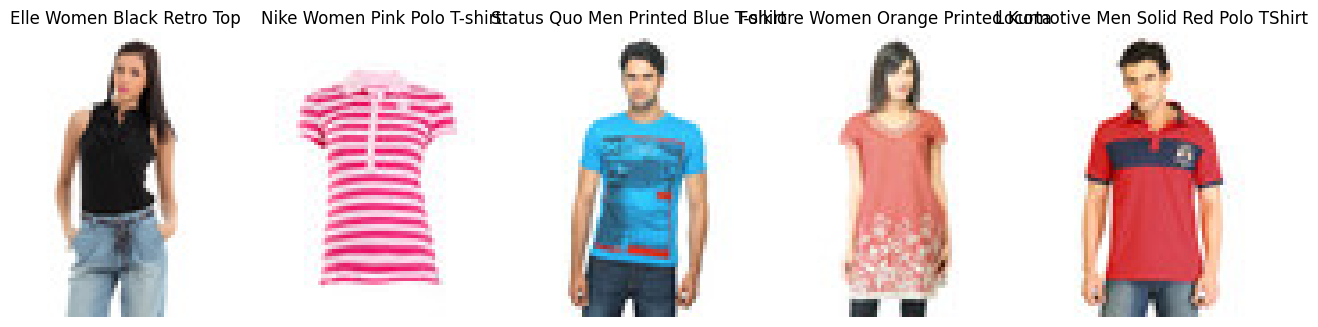

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, i in zip(axes, [0, 1, 2, 3, 4]):
    ax.imshow(images[i])# affiche images[i]
    ax.set_title(titres[i])# titre du graphique : le titre du produit et son étiquette
    ax.axis("off")
plt.show()

<details>
<summary>💡 Voir la solution (essaie d'abord !)</summary>

```python
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, i in zip(axes, [0, 1, 2, 3, 4]):
    ax.imshow(images[i])
    ax.set_title(f"{titres[i][:30]}\n→ {etiquettes[i]}", fontsize=9)
    ax.axis("off")
plt.show()
```

</details>

**🤔 Question** : regarde les titres. Le nom de la catégorie y apparaît-il souvent ? Qu'est-ce que ça laisse présager pour un modèle qui n'utiliserait que le texte ? (On y reviendra en partie 6.)

## 2. Transformer une image en vecteur

Un réseau de neurones ne sait manipuler que des nombres. Il faut donc transformer chaque image en **vecteur** qui résume son contenu.

On ne part pas de zéro : **ResNet18** a déjà été entraîné sur plus d'un million de photos. Il se termine par une couche `fc` qui range l'image dans 1 000 catégories. Juste avant cette couche, l'image est résumée en **512 nombres** : c'est ce résumé qu'on veut.

In [12]:
poids = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=poids)
preparer = poids.transforms()   # redimensionne et normalise l'image comme ResNet l'attend

print("Dernière couche :", resnet.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]

Dernière couche : Linear(in_features=512, out_features=1000, bias=True)


### ✏️ Exercice 3 — Retirer la dernière couche

Remplace `resnet.fc` par une couche qui ne fait rien : `torch.nn.Identity()`. Le modèle renverra alors directement le vecteur de 512 nombres.

In [13]:
resnet.fc = torch.nn.Identity()

resnet = resnet.eval().to(APPAREIL)   # eval() : mode « utilisation », pas « entraînement »

<details>
<summary>💡 Voir la solution (essaie d'abord !)</summary>

```python
resnet.fc = torch.nn.Identity()
```

</details>

In [14]:
# ✅ Vérification : une image doit donner un vecteur de 512 nombres
with torch.no_grad():
    une_image = preparer(images[0]).unsqueeze(0).to(APPAREIL)   # forme (1, 3, 224, 224)
    vecteur = resnet(une_image)
print("Forme de la sortie :", tuple(vecteur.shape))
assert tuple(vecteur.shape) == (1, 512), "on attend (1, 512) : as-tu bien remplacé resnet.fc ?"
print("Exercice 3 réussi ✅")

Forme de la sortie : (1, 512)
Exercice 3 réussi ✅


In [24]:
# La fonction qui traite toutes les images, par paquets de 64.
@torch.no_grad()   # on ne calcule pas de gradients : ResNet est « gelé »
def vecteurs_images(images, lot=64):
    sorties = []
    for debut in range(0, len(images), lot):
        paquet = torch.stack([preparer(im) for im in images[debut:debut + lot]])
        sorties.append(resnet(paquet.to(APPAREIL)).cpu())
    return torch.cat(sorties).numpy()

## 3. Transformer un texte en vecteur

Même idée pour le texte, avec **DistilBERT**, un modèle de langue pré-entraîné. Deux étapes :
1. Le **tokenizer** découpe le titre en morceaux (*tokens*) et les remplace par des numéros.
2. DistilBERT renvoie **un vecteur de 768 nombres par token**.

In [15]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert = AutoModel.from_pretrained("distilbert-base-uncased").eval().to(APPAREIL)

print("Titre  :", titres[0])
print("Tokens :", tokenizer.tokenize(titres[0]))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Titre  : Elle Women Black Retro Top
Tokens : ['elle', 'women', 'black', 'retro', 'top']


In [16]:
# Deux titres de longueurs différentes : le plus court est complété par du « remplissage ».
exemple = tokenizer(titres[:2], padding=True, truncation=True, max_length=32, return_tensors="pt").to(APPAREIL)
with torch.no_grad():
    par_mot = bert(**exemple).last_hidden_state

print("Forme de la sortie :", tuple(par_mot.shape), "= (titres, tokens, 768)")
print("Masque :")
print(exemple["attention_mask"])   # 1 = vrai token, 0 = remplissage

Forme de la sortie : (2, 9, 768) = (titres, tokens, 768)
Masque :
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')


Problème : on a un vecteur **par token**, et on veut **un seul vecteur par titre**. La solution la plus simple est de faire la **moyenne** des vecteurs des tokens, en ignorant le remplissage.

### ✏️ Exercice 4 — La moyenne masquée

Complète la fonction. Le masque vaut 1 pour un vrai token et 0 pour du remplissage.

*Indice : multiplie `par_mot` par le masque pour mettre le remplissage à zéro, puis additionne le long de l'axe des tokens avec `.sum(1)`. Le nombre de vrais tokens est `masque.sum(1)`.*

In [18]:
def moyenne_des_tokens(par_mot, masque):
    # par_mot : forme (titres, tokens, 768)
    # masque  : forme (titres, tokens)
    masque = masque.unsqueeze(-1)      # forme (titres, tokens, 1) pour pouvoir multiplier
    somme = (par_mot *masque).sum(1)
    nombre = masque.sum(1)
    return somme / nombre

In [19]:
# ✅ Vérification sur un mini-exemple : 1 titre, 3 tokens dont le dernier est du remplissage.
test_mots = torch.tensor([[[1., 1.], [3., 3.], [100., 100.]]])
test_masque = torch.tensor([[1, 1, 0]])
resultat = moyenne_des_tokens(test_mots, test_masque)
print("Résultat :", resultat)
assert torch.allclose(resultat, torch.tensor([[2., 2.]])), "on attend [[2, 2]] : le 100 (remplissage) doit être ignoré"
print("Exercice 4 réussi ✅")

Résultat : tensor([[2., 2.]])
Exercice 4 réussi ✅


In [22]:
@torch.no_grad()
def vecteurs_textes(titres, lot=64):
    sorties = []
    for debut in range(0, len(titres), lot):
        entree = tokenizer(titres[debut:debut + lot], padding=True, truncation=True,
                           max_length=32, return_tensors="pt").to(APPAREIL)
        par_mot = bert(**entree).last_hidden_state
        sorties.append(moyenne_des_tokens(par_mot, entree["attention_mask"]).cpu())
    return torch.cat(sorties).numpy()

## 4. Calculer tous les vecteurs

On calcule les vecteurs **une seule fois**. Comme ResNet et DistilBERT sont gelés, leurs sorties ne changeront jamais : inutile de les recalculer à chaque étape de l'entraînement. C'est ce qui rend ce projet rapide.

⏱️ Environ 1 minute avec GPU, 10 à 15 minutes sans.

In [25]:
X_img = vecteurs_images(images)
X_txt = vecteurs_textes(titres)

# Les étiquettes en texte deviennent des numéros : 0, 1, 2...
noms_classes = np.array(sorted(set(etiquettes)))
numero = {nom: i for i, nom in enumerate(noms_classes)}
y = np.array([numero[e] for e in etiquettes])

print("Images :", X_img.shape)
print("Textes :", X_txt.shape)
print("Étiquettes :", y.shape, "→", list(noms_classes))

Images : (5000, 512)
Textes : (5000, 768)
Étiquettes : (5000,) → [np.str_('Casual Shoes'), np.str_('Handbags'), np.str_('Heels'), np.str_('Kurtas'), np.str_('Shirts'), np.str_('Sports Shoes'), np.str_('Sunglasses'), np.str_('Tops'), np.str_('Tshirts'), np.str_('Watches')]


Chaque produit est maintenant décrit par **512 nombres (image)** et **768 nombres (texte)**. Les deux modalités parlent enfin la même langue : celle des vecteurs.

## 5. Préparer l'entraînement

On découpe les produits en trois groupes :
- **entraînement (70 %)** : le modèle apprend dessus
- **validation (15 %)** : pour choisir le meilleur moment où s'arrêter
- **test (15 %)** : mis de côté, pour la note finale

In [26]:
indices = np.arange(len(y))
i_train, i_reste = train_test_split(indices, test_size=0.30, stratify=y, random_state=GRAINE)
i_val, i_test = train_test_split(i_reste, test_size=0.50, stratify=y[i_reste], random_state=GRAINE)
print(len(i_train), "entraînement /", len(i_val), "validation /", len(i_test), "test")

3500 entraînement / 750 validation / 750 test


In [27]:
print(f"Image : moyenne {X_img.mean():.2f}, écart-type {X_img.std():.2f}")
print(f"Texte : moyenne {X_txt.mean():.2f}, écart-type {X_txt.std():.2f}")

Image : moyenne 0.81, écart-type 0.98
Texte : moyenne -0.01, écart-type 0.27


Les deux types de vecteurs n'ont **pas la même échelle**. Si on les colle tels quels, la modalité aux plus grands nombres risque de dominer. C'est un piège classique du multimodal.

### ✏️ Exercice 5 — Normaliser

Complète la fonction pour que chaque colonne ait une moyenne de 0 et un écart-type de 1.

Point important : la moyenne et l'écart-type se calculent **uniquement sur l'entraînement**, puis s'appliquent aux trois groupes. Sinon le modèle « verrait » indirectement les données de test.

*Indice : `train.mean(0)` donne la moyenne de chaque colonne, `train.std(0)` son écart-type.*

In [28]:
def normaliser(train, val, test):
    moyenne = train.mean(0)
    ecart = train.std(0)+ 1e-6        # le petit nombre évite une division par zéro
    return (train - moyenne) / ecart, (val - moyenne) / ecart, (test - moyenne) / ecart

In [29]:
# ✅ Vérification
a, b, c = normaliser(X_img[i_train], X_img[i_val], X_img[i_test])
assert a.shape == X_img[i_train].shape
assert abs(a.mean()) < 1e-3, "la moyenne de l'entraînement normalisé doit être proche de 0"
assert np.abs(a.mean(0)).max() < 1e-2, "chaque COLONNE doit avoir une moyenne de 0 : utilise mean(0)"
print("Exercice 5 réussi ✅")

Exercice 5 réussi ✅


In [30]:
def en_tenseur(tableau):
    return torch.tensor(tableau, dtype=torch.float32)

img_tr, img_va, img_te = [en_tenseur(a) for a in normaliser(X_img[i_train], X_img[i_val], X_img[i_test])]
txt_tr, txt_va, txt_te = [en_tenseur(a) for a in normaliser(X_txt[i_train], X_txt[i_val], X_txt[i_test])]
y_tr, y_va, y_te = torch.tensor(y[i_train]), torch.tensor(y[i_val]), torch.tensor(y[i_test])

## 6. Le modèle multimodal

Voici le cœur du projet. L'architecture s'appelle la **fusion par concaténation** :

```
vecteur image (512) ─┐
                     ├─ collés bout à bout (1280) ─> petit réseau ─> un score par catégorie
vecteur texte (768) ─┘
```

Pour pouvoir comparer, la même classe pourra aussi fonctionner avec une seule modalité (`utiliser_image=False` ou `utiliser_texte=False`).

### ✏️ Exercice 6 — Écrire la fusion

Complète les deux `...` :
1. `dim_entree` : la taille du vecteur qui entre dans le réseau. Elle dépend des modalités utilisées.
2. Dans `forward` : colle les morceaux bout à bout.

*Indice : `torch.cat(liste_de_tenseurs, dim=1)` colle des tenseurs côte à côte. `dim=1` signifie « le long des colonnes » : on garde le même nombre de produits, on allonge chaque vecteur.*

In [31]:
class ClassifieurMultimodal(nn.Module):
    def __init__(self, dim_image, dim_texte, n_classes, utiliser_image=True, utiliser_texte=True):
        super().__init__()
        self.utiliser_image = utiliser_image
        self.utiliser_texte = utiliser_texte

        dim_entree = 0
        if utiliser_image:
            dim_entree += dim_image
        if utiliser_texte:
            dim_entree += dim_texte

        self.reseau = nn.Sequential(
            nn.Linear(dim_entree, 256),   # couche cachée
            nn.ReLU(),
            nn.Dropout(0.3),              # limite le « par cœur »
            nn.Linear(256, n_classes),    # un score par catégorie
        )

    def forward(self, image, texte):
        morceaux = []
        if self.utiliser_image:
            morceaux.append(image)
        if self.utiliser_texte:
            morceaux.append(texte)
        fusion = torch.cat(morceaux, dim=1)
        return self.reseau(fusion)

In [32]:
# ✅ Vérification : on teste les trois variantes sur 4 produits
n = len(noms_classes)
for img_on, txt_on, attendu in [(True, True, 1280), (True, False, 512), (False, True, 768)]:
    m = ClassifieurMultimodal(512, 768, n, utiliser_image=img_on, utiliser_texte=txt_on)
    assert m.reseau[0].in_features == attendu, f"dim_entree devrait valoir {attendu} pour image={img_on}, texte={txt_on}"
    sortie = m(img_tr[:4], txt_tr[:4])
    assert tuple(sortie.shape) == (4, n), f"sortie attendue (4, {n}), obtenue {tuple(sortie.shape)}"
print("Exercice 6 réussi ✅  Tu viens d'écrire un modèle multimodal.")

Exercice 6 réussi ✅  Tu viens d'écrire un modèle multimodal.


## 7. L'entraînement

Entraîner, c'est répéter quatre gestes sur des petits paquets de produits :

1. **Remettre les gradients à zéro** : `optimiseur.zero_grad()`
2. **Prédire** : `scores = modele(images, textes)`
3. **Mesurer l'erreur et calculer les gradients** : `erreur = fonction_perte(scores, bonnes_reponses)` puis `erreur.backward()`
4. **Corriger les poids** : `optimiseur.step()`

### ✏️ Exercice 7 — La boucle d'entraînement

Complète les quatre étapes dans la fonction ci-dessous. Les variables du paquet courant s'appellent `img_tr[paquet]`, `txt_tr[paquet]` et `y_tr[paquet]`.

In [33]:
def precision(modele, img, txt, y):
    """Proportion de bonnes réponses, et les prédictions."""
    modele.eval()
    with torch.no_grad():
        pred = modele(img, txt).argmax(1)   # la catégorie au score le plus élevé
    return (pred == y).float().mean().item(), pred


def entrainer(modele, epoques=30, taille_paquet=64):
    optimiseur = torch.optim.Adam(modele.parameters(), lr=1e-3)
    fonction_perte = nn.CrossEntropyLoss()
    historique = []
    meilleure_val, meilleurs_poids = -1.0, None

    for epoque in range(epoques):
        modele.train()
        ordre = torch.randperm(len(y_tr))                 # on mélange à chaque époque
        for debut in range(0, len(y_tr), taille_paquet):
            paquet = ordre[debut:debut + taille_paquet]

            optimiseur.zero_grad() # 1. remettre les gradients à zéro
            scores = modele(img_tr[paquet],txt_tr[paquet])# 2. prédire : scores = ...
            erreur = fonction_perte(scores, y_tr[paquet]) # 3. mesurer l'erreur et appeler .backward()
            erreur.backward()                             # 4. corriger les poids
            optimiseur.step()

        # À la fin de chaque époque : on note la précision sur la validation
        # et on garde en mémoire la meilleure version du modèle.
        val, _ = precision(modele, img_va, txt_va, y_va)
        historique.append(val)
        if val > meilleure_val:
            meilleure_val = val
            meilleurs_poids = {k: v.clone() for k, v in modele.state_dict().items()}

    modele.load_state_dict(meilleurs_poids)
    return historique

In [34]:
# ✅ Vérification : après 3 époques, le modèle doit faire bien mieux que le hasard (10 %)
torch.manual_seed(GRAINE)
essai = ClassifieurMultimodal(512, 768, len(noms_classes))
h = entrainer(essai, epoques=3)
print("Précision validation après 3 époques :", f"{h[-1]:.1%}")
assert h[-1] > 0.5, "le modèle n'apprend pas : vérifie les 4 étapes de la boucle"
print("Exercice 7 réussi ✅")

Précision validation après 3 époques : 97.5%
Exercice 7 réussi ✅


## 8. La comparaison : une modalité ou deux ?

C'est l'expérience qui donne son sens au projet. On entraîne trois modèles **sur exactement les mêmes produits** ; la seule différence est ce que chacun a le droit de regarder.

**🤔 Avant d'exécuter, fais un pari** : lequel sera le meilleur ? Lequel sera le moins bon ? De combien ?

In [35]:
variantes = {
    "image seule":   dict(utiliser_image=True,  utiliser_texte=False),
    "texte seul":    dict(utiliser_image=False, utiliser_texte=True),
    "image + texte": dict(utiliser_image=True,  utiliser_texte=True),
}

scores, predictions, historiques = {}, {}, {}
for nom, options in variantes.items():
    torch.manual_seed(GRAINE)
    modele = ClassifieurMultimodal(512, 768, len(noms_classes), **options)
    historiques[nom] = entrainer(modele)
    scores[nom], pred = precision(modele, img_te, txt_te, y_te)
    predictions[nom] = pred.numpy()
    print(f"{nom:<14} précision sur le test : {scores[nom]:.1%}")

image seule    précision sur le test : 91.6%
texte seul     précision sur le test : 97.3%
image + texte  précision sur le test : 98.3%


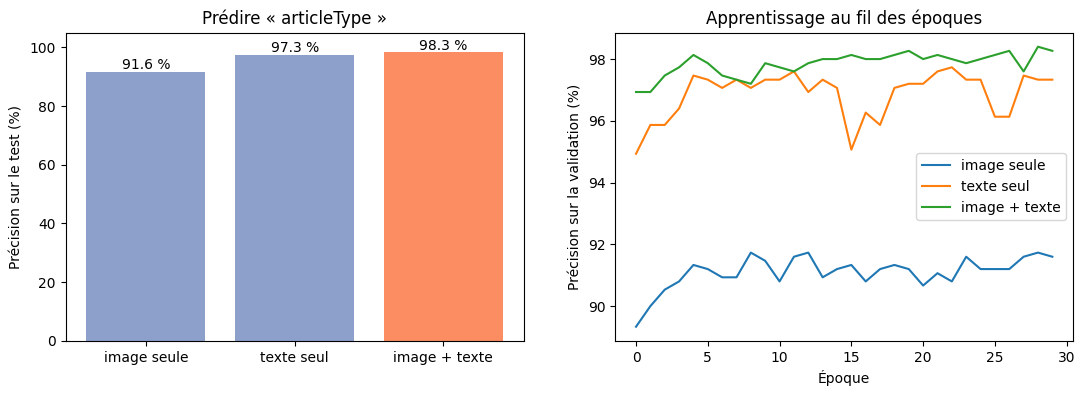

In [36]:
fig, (g, d) = plt.subplots(1, 2, figsize=(13, 4))

barres = g.bar(list(scores), [100 * s for s in scores.values()], color=["#8da0cb", "#8da0cb", "#fc8d62"])
g.bar_label(barres, fmt="%.1f %%")
g.set_ylim(0, 105)
g.set_ylabel("Précision sur le test (%)")
g.set_title(f"Prédire « {CIBLE} »")

for nom, h in historiques.items():
    d.plot([100 * v for v in h], label=nom)
d.set_xlabel("Époque")
d.set_ylabel("Précision sur la validation (%)")
d.set_title("Apprentissage au fil des époques")
d.legend()
plt.show()

**🤔 Questions**
1. Ton pari était-il juste ?
2. Le texte seul est probablement déjà excellent. Pourquoi ? (Repense à ta réponse de la partie 1.)
3. La fusion fait-elle mieux que la meilleure des deux modalités ? De beaucoup ?

## 9. Comprendre où la fusion aide

Un score global ne dit pas tout. Regardons produit par produit.

In [37]:
vrai = y[i_test]
ok_img = predictions["image seule"] == vrai
ok_txt = predictions["texte seul"] == vrai
ok_fus = predictions["image + texte"] == vrai

print(f"Sur {len(vrai)} produits de test :")
print("  les trois modèles ont raison             :", (ok_img & ok_txt & ok_fus).sum())
print("  fusion juste alors que l'image se trompe :", (ok_fus & ~ok_img).sum())
print("  fusion juste alors que le texte se trompe:", (ok_fus & ~ok_txt).sum())
print("  fusion fausse alors qu'un autre a raison :", (~ok_fus & (ok_img | ok_txt)).sum())

Sur 750 produits de test :
  les trois modèles ont raison             : 677
  fusion juste alors que l'image se trompe : 55
  fusion juste alors que le texte se trompe: 8
  fusion fausse alors qu'un autre a raison : 6


### ✏️ Exercice 8 — Voir les produits sauvés par la fusion

Affiche jusqu'à 5 produits que la fusion classe bien alors que **le texte seul se trompe**. Pour chacun, montre l'image, le titre, la vraie catégorie et la prédiction du texte seul.

*Indices :*
- *`np.where(condition)[0]` donne les positions où une condition est vraie.*
- *Une position `p` dans le test correspond au produit numéro `i_test[p]` dans `images` et `titres`.*
- *`noms_classes[k]` donne le nom de la catégorie numéro `k`.*

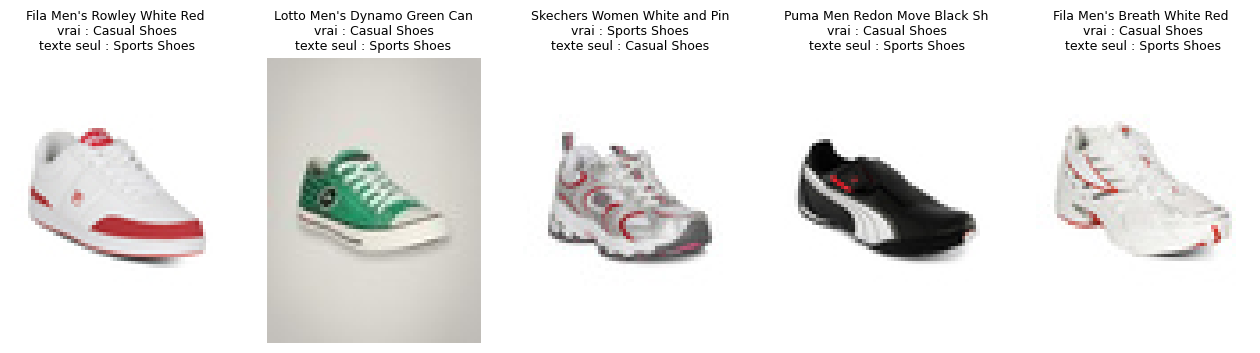

In [39]:
positions = np.where(ok_fus & ~ok_txt)[0]
# positions (dans le test) où ok_fus est vrai et ok_txt est faux

if len(positions) == 0:
    print("Aucun cas : le texte seul ne se trompe jamais là où la fusion réussit.")
else:
    k = min(5, len(positions))
    fig, axes = plt.subplots(1, k, figsize=(3.2 * k, 4.5), squeeze=False)
    for ax, p in zip(axes[0], positions[:k]):
        produit = i_test[p]
        ax.imshow(images[produit])              # affiche l'image, et en titre : le titre du produit,
        ax.set_title(
            f"{titres[produit][:28]}\n"
            f"vrai : {noms_classes[vrai[p]]}\n"
            f"texte seul : {noms_classes[predictions['texte seul'][p]]}",
            fontsize=9,)
        ax.axis("off")
    plt.show()

**🤔 Question** : en regardant ces produits, comprends-tu pourquoi le titre ne suffisait pas et ce que l'image a apporté ?

## 10. À toi de jouer

Tu as maintenant un pipeline multimodal complet. Les vraies leçons viennent en le modifiant.

### Expérience A — Changer la cible (la plus instructive)
Tout en haut du notebook, remplace `CIBLE = "articleType"` par `CIBLE = "baseColour"`, puis relance tout (*Exécution → Tout exécuter*). La vérification de l'exercice 1 échouera sur « Tshirts » : supprime simplement cette ligne.

Avant de lancer, fais un pari : quelle modalité sera la meilleure pour deviner une **couleur** ? La fusion aidera-t-elle plus qu'avant ? Essaie ensuite `"season"` puis `"usage"`.

### Expérience B — Moins de données
Passe `N_EXEMPLES` à 500. Quel modèle souffre le plus ?

### Expérience C — Une autre façon de fusionner
Au lieu de coller les vecteurs, ramène chacun à la même taille avec sa propre couche (`nn.Linear(512, 256)` et `nn.Linear(768, 256)`), puis **additionne-les**. Est-ce mieux ou moins bien que la concaténation ?

### Expérience D — Une modalité manquante
Au moment du test, remplace les vecteurs texte par des zéros : `precision(modele, img_te, torch.zeros_like(txt_te), y_te)`. Le modèle multimodal s'en sort-il aussi bien que le modèle « image seule » ? Pourquoi, à ton avis ?

## Ce qu'il faut retenir

- Le multimodal repose sur une idée simple : **tout transformer en vecteurs**, puis les combiner.
- Des modèles pré-entraînés gelés font l'essentiel du travail ; on n'entraîne qu'un petit réseau par-dessus.
- Il faut **toujours comparer** au meilleur modèle à une seule modalité : la fusion n'aide que si les modalités apportent des informations **complémentaires**.
- Les détails comptent : normaliser chaque modalité, et ne jamais utiliser le test pour autre chose que la note finale.